# **Él sabe de ti, sabe de mí...**
## **Santa Claus llegó a la ciudad**
### *Santa y Satán caminan de la mano*

Por Fabián Salinas y Alessandro Lavezzi

# Entorno

In [6]:
import io
import os
import random
import zipfile
from PIL import Image
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, MaxPool2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers

c:\Users\Lenovo\Desktop\UDD puta\2T 2026\frameworks ia\viejopascuero\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Pre procesamiento de data

In [7]:
train_datagen = ImageDataGenerator(rescale = 1/255)
test_datagen = ImageDataGenerator(rescale = 1/255)

Para la próxima celda debes descargar el dataset adjunto en el tutorial de kaggle, y la ruta que dejes para aquella carpeta con los datos dejarla en la variable "ruta".

In [17]:
BATCH = 32
ruta = r"C:\Users\Lenovo\Desktop\UDD puta\2T 2026\frameworks ia\is that santa"

training_dataset = train_datagen.flow_from_directory(ruta+"\\train",target_size = (150,150),class_mode='binary',batch_size = BATCH)
test_dataset = test_datagen.flow_from_directory(ruta+"\\test",target_size = (150,150),class_mode = 'binary',batch_size = BATCH)


Found 614 images belonging to 2 classes.


Found 616 images belonging to 2 classes.


# Modelo de Red Neuronal Convolucional (CNN)

Es un modelo de Deep Learning diseñado para procesar y analizar datos visuales. Ideal para atrapar a los intrépidos y ardientes viejitos pascueros.

In [21]:
model_CNN = tf.keras.models.Sequential([
    layers.Conv2D(16, (3, 3), input_shape=(150, 150, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2), 
    
    layers.Flatten(),  # Here the output is flatten to feed into fully connected layers
    
    layers.Dense(512, activation='relu'),  # The layer is Fully connected and activted by the relu function
    
    layers.Dense(1, activation='sigmoid')  # The Output layer is activated by the sigmoid activation for binary classification
])

model_CNN.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model_CNN.summary()

# Data augmentation is applied to prevent overfitting
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)


history = model_CNN.fit(
      training_dataset,
      steps_per_epoch=100,  # the model will do 100 steps (batches of samples) before declaring one epoch finished
      epochs=10, 
      validation_data=test_dataset,
      validation_steps=50)  # 50 steps to draw before stopping when performing validation at the end of every epoch

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
 20/100 ━━━━━━━━━━━━━━━━━━━━ 44s 557ms/step - accuracy: 0.6040 - loss: 0.7990

c:\Users\Lenovo\Desktop\UDD puta\2T 2026\frameworks ia\viejopascuero\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.6564 - loss: 0.6854 - val_accuracy: 0.7500 - val_loss: 0.5098
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.8355 - loss: 0.3968 - val_accuracy: 0.8604 - val_loss: 0.3704
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.8567 - loss: 0.3522 - val_accuracy: 0.8912 - val_loss: 0.2474
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.8697 - loss: 0.3062 - val_accuracy: 0.9107 - val_loss: 0.2318
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - accuracy: 0.9007 - loss: 0.2676 - val_accuracy: 0.9107 - val_loss: 0.2437
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.9023 - loss: 0.2474 - val_accuracy: 0.8994 - val_loss: 0.2548
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.8730 - loss: 0.3104 - val_accuracy: 0.8929 - val_loss: 0.2441
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.9072 - loss: 0.2542 - val

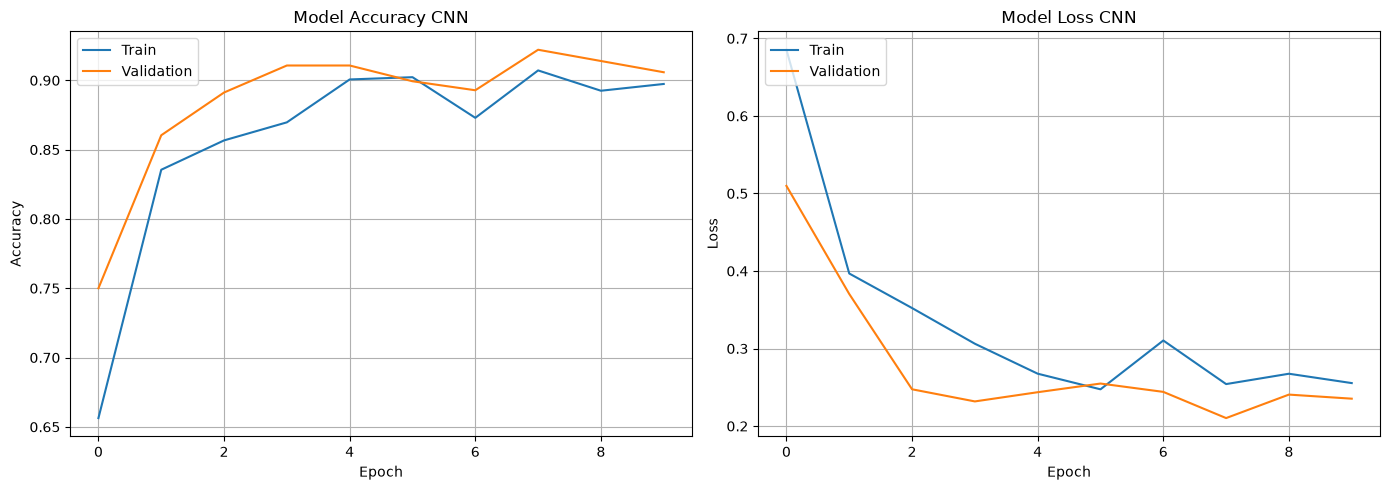

In [22]:
# This code is plottin the training & validation metrics
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy CNN')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss CNN')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# CNN Regularizada

In [23]:
# Here we are defining the model with L1 and L2 regularization
Regularized_model_CNN = tf.keras.models.Sequential([
    layers.Conv2D(16, (3, 3), input_shape=(150, 150, 3), activation='relu',
                  kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),
    layers.MaxPooling2D(2, 2),  
    
    layers.Conv2D(32, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),
    layers.MaxPooling2D(2, 2),  
    
    layers.Conv2D(64, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),
    layers.MaxPooling2D(2, 2),
    
   
    layers.Flatten(),
    
    # The layer is fully connected with L2 regularization
    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01)),
    
    layers.Dense(1, activation='sigmoid')
])

Regularized_model_CNN.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Regularized_model_CNN.summary()

history = Regularized_model_CNN.fit(
      training_dataset,
      steps_per_epoch=100, 
      epochs=10,
      validation_data=test_dataset,
      validation_steps=50)

c:\Users\Lenovo\Desktop\UDD puta\2T 2026\frameworks ia\viejopascuero\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - accuracy: 0.5684 - loss: 14.8704 - val_accuracy: 0.5942 - val_loss: 10.2991
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.7622 - loss: 8.2356 - val_accuracy: 0.8620 - val_loss: 6.3527
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.7915 - loss: 5.2969 - val_accuracy: 0.7776 - val_loss: 4.1943
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.8094 - loss: 3.5287 - val_accuracy: 0.8847 - val_loss: 2.8131
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.8257 - loss: 2.5264 - val_accuracy: 0.8458 - val_loss: 2.2200
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8567 - loss: 1.9762 - val_accuracy: 0.8279 - val_loss: 1.7973
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.8550 - loss: 1.6483 - val_accuracy: 0.8588 - val_loss: 1.5123
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.8811 - loss:

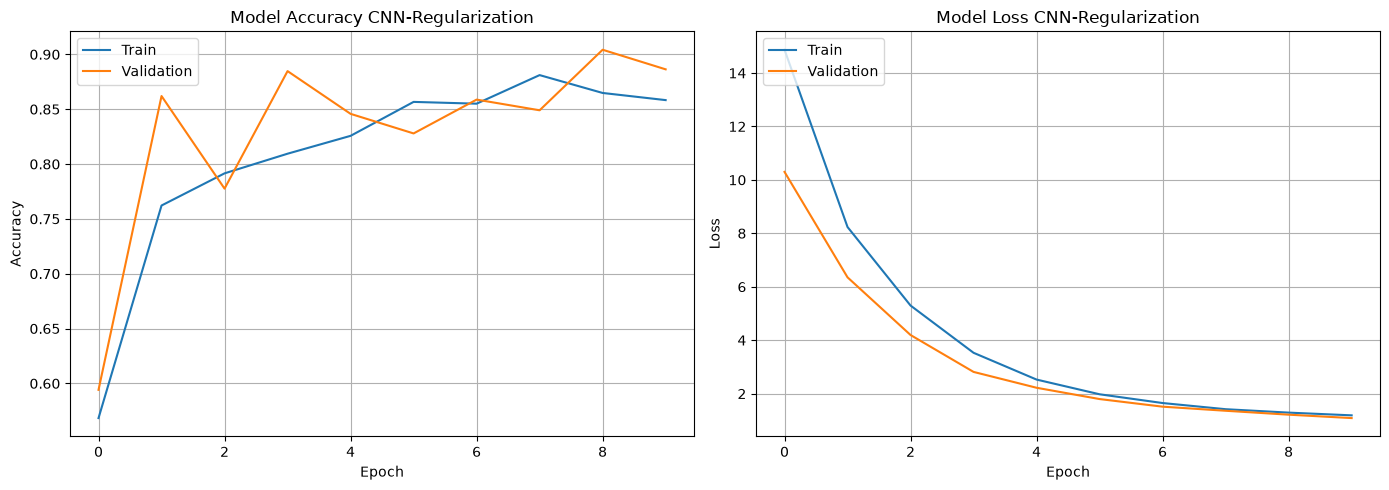

In [24]:
# Here we are plotting training & validation metrics for the Regularized model
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy CNN-Regularization')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss CNN-Regularization')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# Predicciones navideñas

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


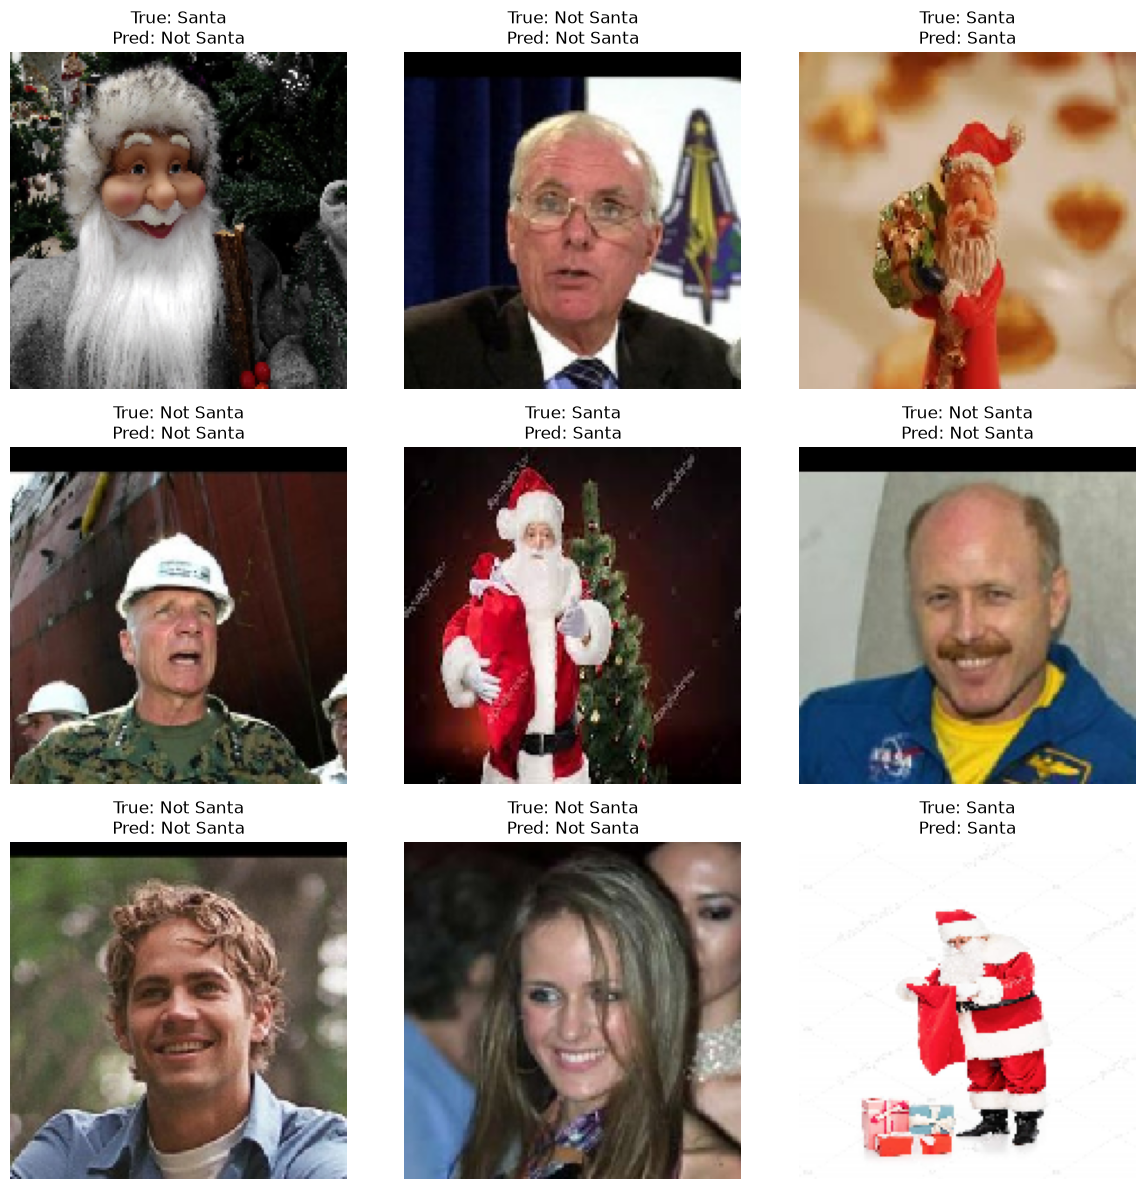

In [25]:
# Here we are getting a batch of images and labels
images, labels = next(test_dataset)

predictions = Regularized_model_CNN.predict(images)
predicted_labels = (predictions > 0.5).astype(int).flatten()  # Converting probabilities to binary labels

# Mapping numerical labels to the classification goals
label_names = {0: "Not Santa", 1: "Santa"}

# Number of images to display (3x3 grid)
num_images = 9

plt.figure(figsize=(12, 12))

for i in range(num_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    true_label = label_names[labels[i]]
    predicted_label = label_names[predicted_labels[i]]
    plt.title(f'True: {true_label}\nPred: {predicted_label}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Felinos navideños malvados...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


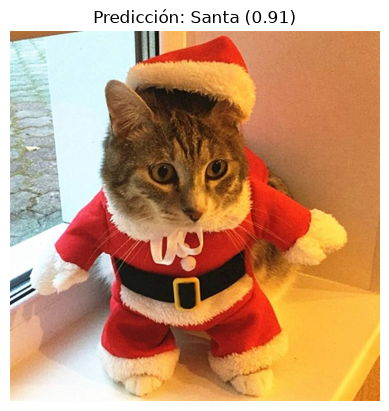

In [26]:
# Carga la imagen y la redimensiona al tamaño que espera el modelo
img_path = r"C:\Users\Lenovo\Desktop\UDD puta\2T 2026\frameworks ia\is that santa\gato_claus.jpg"  # cambia esto
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # añade dimensión de batch

# Predicción
prediction = Regularized_model_CNN.predict(img_array)
label = "Santa" if prediction[0][0] > 0.5 else "Not Santa"

# Visualización
plt.imshow(image.load_img(img_path))
plt.title(f"Predicción: {label} ({prediction[0][0]:.2f})")
plt.axis('off')
plt.show()